# Phase 9 — A traditional WoE points scorecard

Notebook 04 built a LightGBM model and converted its probability into a score.
That is a *model with a score attached*. It is not what a bank deploys.

A deployed application scorecard is a **table of points**. Each characteristic
is binned, each bin carries a fixed number of points, and an applicant's score
is the sum. It can be applied by hand, audited line by line, and explained to
a regulator without reference to the model that produced it:

```
Employment length     < 1 yr    ->  -12 points
                      1-3 yrs   ->   -4 points
                      10+ yrs   ->  +15 points
```

This notebook builds that artefact. The method is the standard one:

1. **Coarse classing** — bin each characteristic, merging bins until the bad
   rate is monotonic, so the scorecard cannot tell a nonsensical story.
2. **WoE transform** — replace each bin with its Weight of Evidence.
3. **Logistic regression on the WoE values** — one coefficient per
   characteristic rather than per bin.
4. **Scale coefficients into points** with the same PDO arithmetic as Phase 8.

The result is compared against LightGBM on the same test set, because the
honest question is what the interpretability costs.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
FIGS = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42

df = pd.read_csv(ROOT / "data" / "lending_club_clean.csv")
TARGET = "bad_loan"
print(f"{df.shape[0]:,} rows | default rate {df[TARGET].mean():.2%}")

163,987 rows | default rate 18.30%


## 9.1 The same split as Phase 5

Identical `random_state` and proportions, so the Gini comparison at the end is
like for like. Binning and WoE are learned on the **training fold only** —
they are fitted quantities, and computing them on all the data would leak.

In [2]:
X = df.drop(columns=[TARGET])
y = df[TARGET]
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)
train = X_train.copy(); train[TARGET] = y_train.values
test = X_test.copy(); test[TARGET] = y_test.values
print(f"Train {len(train):,} | Test {len(test):,}")

# Characteristics a credit officer would recognise. Deliberately a short list:
# a real scorecard is typically 8-12 characteristics, not 20.
NUMERIC = ["loan_to_income", "revol_util", "dti", "annual_inc",
           "total_acc", "longest_credit_length", "emp_length"]
CATEGORICAL = ["term_months", "purpose", "home_ownership", "verification_status"]
print(f"\n{len(NUMERIC)} numeric + {len(CATEGORICAL)} categorical characteristics")

Train 98,391 | Test 32,798

7 numeric + 4 categorical characteristics


## 9.2 Coarse classing with enforced monotonicity

The profiling at the top of this notebook showed that fine quantile bins are
**not** monotonic for several characteristics: `emp_length` wobbles between
17% and 19%, `loan_amnt` reverses mid-range. Those reversals are noise, and a
scorecard that prices them would say things like *"11 accounts is riskier than
12, which is riskier than 13, which is safer than 14."* Indefensible in front
of a regulator, and it will not replicate out of sample.

So bins are merged until the bad rate moves in one direction. This is the step
that separates a scorecard from a model: it trades a little fit for a
structure that can be defended line by line.

In [3]:
def monotonic_bins(series, target, max_bins=8, min_frac=0.05):
    """Quantile-bin, then merge adjacent bins until the bad rate is monotonic
    and every bin holds at least `min_frac` of the population."""
    s = series.copy()
    valid = s.notna()
    edges = list(np.unique(np.nanquantile(s[valid], np.linspace(0, 1, max_bins + 1))))
    if len(edges) < 3:
        return [-np.inf, np.inf]
    edges[0], edges[-1] = -np.inf, np.inf

    def stats(e):
        b = pd.cut(s, e, duplicates="drop")
        g = pd.DataFrame({"b": b, "y": target}).groupby("b", observed=True).y.agg(["size", "mean"])
        return g

    # Decide direction from the correlation on the raw values.
    direction = np.sign(np.corrcoef(s[valid], target[valid])[0, 1]) or 1.0

    for _ in range(60):
        g = stats(edges)
        if len(g) < 2:
            break
        rates, sizes = g["mean"].values, g["size"].values
        n = sizes.sum()

        # Merge the worst monotonicity violation, else the smallest thin bin.
        diffs = np.diff(rates) * direction
        bad = np.where(diffs < 0)[0]
        thin = np.where(sizes / n < min_frac)[0]
        if len(bad):
            i = bad[np.argmin(diffs[bad])]
        elif len(thin):
            i = thin[0] if thin[0] < len(rates) - 1 else thin[0] - 1
        else:
            break
        del edges[i + 1]
        if len(edges) <= 2:
            break
    return edges


BIN_EDGES = {c: monotonic_bins(train[c], train[TARGET]) for c in NUMERIC}
for c, e in BIN_EDGES.items():
    shown = [f"{v:,.4g}" for v in e[1:-1]]
    print(f"{c:<24}{len(e) - 1} bins   cut points: {shown}")

loan_to_income          8 bins   cut points: ['0.08', '0.1177', '0.1526', '0.1883', '0.2286', '0.2778', '0.3462']
revol_util              8 bins   cut points: ['21.5', '35.7', '46.5', '56', '65', '74.3', '84.7']
dti                     8 bins   cut points: ['6.81', '10.25', '13.03', '15.64', '18.3', '21.26', '24.89']
annual_inc              8 bins   cut points: ['3.5e+04', '4.5e+04', '5.2e+04', '6.1e+04', '7.2e+04', '8.55e+04', '1.1e+05']
total_acc               8 bins   cut points: ['12', '16', '20', '23', '27', '32', '38']
longest_credit_length   7 bins   cut points: ['8', '10', '12', '14', '16', '18']
emp_length              3 bins   cut points: ['1', '8']


## 9.3 Weight of Evidence per bin

$$WoE = \ln\left(\frac{\%\ good}{\%\ bad}\right)$$

Positive WoE means the bin is better than average, negative means worse.
Missing values get their **own bin** rather than being imputed — a scorecard
can price "not stated" explicitly, which is exactly what the Phase 3 finding
about `emp_length` called for.

In [4]:
def bin_series(s, col):
    if col in BIN_EDGES:
        out = pd.cut(s, BIN_EDGES[col]).astype(object)
    else:
        out = s.astype(object)
    return pd.Series(out, index=s.index).fillna("MISSING")


def woe_table(frame, col, target_col=TARGET):
    b = bin_series(frame[col], col)
    g = pd.DataFrame({"bin": b, "y": frame[target_col]}).groupby("bin", observed=True).y.agg(
        ["size", "sum"])
    g.columns = ["n", "bad"]
    g["good"] = g.n - g.bad
    # Laplace smoothing so an all-good or all-bad bin cannot produce infinity.
    g["pct_bad"] = (g.bad + 0.5) / (g.bad.sum() + 0.5 * len(g))
    g["pct_good"] = (g.good + 0.5) / (g.good.sum() + 0.5 * len(g))
    g["woe"] = np.log(g.pct_good / g.pct_bad)
    g["iv"] = (g.pct_good - g.pct_bad) * g.woe
    g["bad_rate"] = g.bad / g.n
    g["pct_of_book"] = g.n / g.n.sum()
    return g


WOE_MAPS, IV = {}, {}
for col in NUMERIC + CATEGORICAL:
    t = woe_table(train, col)
    WOE_MAPS[col] = t.woe.to_dict()
    IV[col] = t.iv.sum()

iv_rank = pd.Series(IV).sort_values(ascending=False).round(4)
print("Information Value by characteristic\n")
print(iv_rank.to_string())

Information Value by characteristic

loan_to_income           0.1349
term_months              0.1265
revol_util               0.0779
dti                      0.0691
annual_inc               0.0613
purpose                  0.0357
verification_status      0.0251
home_ownership           0.0173
total_acc                0.0126
emp_length               0.0086
longest_credit_length    0.0061


### Dropping characteristics that earn nothing

A scorecard is a document people have to use. Characteristics below IV 0.02
contribute nothing measurable and are removed — every extra row is a row a
credit officer has to read and an auditor has to check.

In [5]:
KEEP = [c for c in NUMERIC + CATEGORICAL if IV[c] >= 0.02]
DROPPED = [c for c in NUMERIC + CATEGORICAL if c not in KEEP]
print(f"Keeping {len(KEEP)}: {KEEP}")
print(f"Dropping {len(DROPPED)}: {DROPPED}")

Keeping 7: ['loan_to_income', 'revol_util', 'dti', 'annual_inc', 'term_months', 'purpose', 'verification_status']
Dropping 4: ['total_acc', 'longest_credit_length', 'emp_length', 'home_ownership']


In [6]:
def to_woe(frame):
    out = pd.DataFrame(index=frame.index)
    for col in KEEP:
        b = bin_series(frame[col], col)
        out[col] = b.map(WOE_MAPS[col]).astype(float).fillna(0.0)
    return out


Xtr_woe, Xte_woe = to_woe(train), to_woe(test)
print(f"WoE matrix: {Xtr_woe.shape[0]:,} x {Xtr_woe.shape[1]}")

WoE matrix: 98,391 x 7


## 9.4 Logistic regression on the WoE values

One coefficient per characteristic, not per bin. The bin structure already
carries the shape; the coefficient only sets how much that characteristic
counts overall.

**Every coefficient should be negative.** WoE rises with creditworthiness and
the target is *bad*, so a positive coefficient would mean "better applicants
default more" — a sign flip, and the standard signal that a characteristic is
mis-binned or fighting another. Checked below rather than assumed.

In [7]:
scorecard_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
scorecard_model.fit(Xtr_woe, y_train)

coefs = pd.Series(scorecard_model.coef_[0], index=KEEP)
intercept = float(scorecard_model.intercept_[0])

summary = pd.DataFrame({"coefficient": coefs.round(4), "IV": pd.Series(IV)[KEEP].round(4)})
summary["sign_ok"] = np.where(summary.coefficient < 0, "yes", "SIGN FLIP")
print(summary.sort_values("IV", ascending=False).to_string())
print(f"\nintercept: {intercept:.4f}")
flips = (coefs > 0).sum()
print(f"\nSign flips: {flips}" + ("  <- investigate before shipping" if flips else "  (all correct)"))

                     coefficient      IV sign_ok
loan_to_income           -0.3860  0.1349     yes
term_months              -0.8947  0.1265     yes
revol_util               -0.9155  0.0779     yes
dti                      -0.4658  0.0691     yes
annual_inc               -1.0804  0.0613     yes
purpose                  -1.0566  0.0357     yes
verification_status      -0.2432  0.0251     yes

intercept: -1.4980

Sign flips: 0  (all correct)


## 9.5 Converting coefficients into points

The standard scorecard arithmetic, same anchors as Phase 8 (PDO 20,
600 = 50:1 odds):

$$factor = \frac{PDO}{\ln 2}, \qquad offset = base - factor \times \ln(base\ odds)$$

$$points_{i} = -\left(\beta_i \times WoE_i + \frac{\alpha}{n}\right) \times factor + \frac{offset}{n}$$

The intercept and offset are spread evenly across the *n* characteristics, so
the points for every bin sum to exactly the model's score. Each bin's points
are a fixed integer, computed once and then frozen.

In [8]:
PDO, BASE_SCORE, BASE_ODDS = 20, 600, 50
FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - FACTOR * np.log(BASE_ODDS)
n_chars = len(KEEP)

rows = []
for col in KEEP:
    t = woe_table(train, col)
    for bin_label, r in t.iterrows():
        pts = -(coefs[col] * r.woe + intercept / n_chars) * FACTOR + OFFSET / n_chars
        rows.append({
            "characteristic": col,
            "bin": str(bin_label),
            "population_%": round(r.pct_of_book * 100, 1),
            "bad_rate_%": round(r.bad_rate * 100, 2),
            "WoE": round(r.woe, 4),
            "points": int(round(pts)),
        })

POINTS = pd.DataFrame(rows)
print(f"factor = {FACTOR:.2f}, offset = {OFFSET:.2f}, characteristics = {n_chars}")
print(f"Scorecard has {len(POINTS)} rows across {n_chars} characteristics")

factor = 28.85, offset = 487.12, characteristics = 7
Scorecard has 53 rows across 7 characteristics


## 9.6 The scorecard

**This is the deliverable.** Everything before it was the method; this table
is what a lender would actually deploy, hand to an underwriter, or file with a
model validation team.

In [9]:
for col in KEEP:
    sub = POINTS[POINTS.characteristic == col].copy()
    span = sub.points.max() - sub.points.min()
    print(f"\n=== {col}   (IV {IV[col]:.3f}, point spread {span}) ===")
    print(sub[["bin", "population_%", "bad_rate_%", "WoE", "points"]].to_string(index=False))


=== loan_to_income   (IV 0.135, point spread 12) ===
           bin  population_%  bad_rate_%     WoE  points
  (-inf, 0.08]          12.8       12.47  0.4528      81
 (0.08, 0.118]          12.2       13.16  0.3910      80
(0.118, 0.153]          12.5       14.42  0.2846      79
(0.153, 0.188]          12.5       15.63  0.1903      78
(0.188, 0.229]          12.6       16.96  0.0927      77
(0.229, 0.278]          12.6       19.73 -0.0925      75
(0.278, 0.346]          12.3       24.26 -0.3575      72
  (0.346, inf]          12.5       29.95 -0.6460      69
       MISSING           0.0        0.00  0.4503      81

=== revol_util   (IV 0.078, point spread 24) ===
         bin  population_%  bad_rate_%     WoE  points
(-inf, 21.5]          12.6       11.60  0.5348      90
(21.5, 35.7]          12.5       14.08  0.3127      84
(35.7, 46.5]          12.5       15.71  0.1838      81
(46.5, 56.0]          12.6       17.82  0.0325      77
(56.0, 65.0]          12.4       19.26 -0.0627     

The **point spread** shown for each characteristic is how much it can move an
applicant's score from best bin to worst. That, not the coefficient, is what a
credit officer cares about: it is the characteristic's real influence on a
decision.

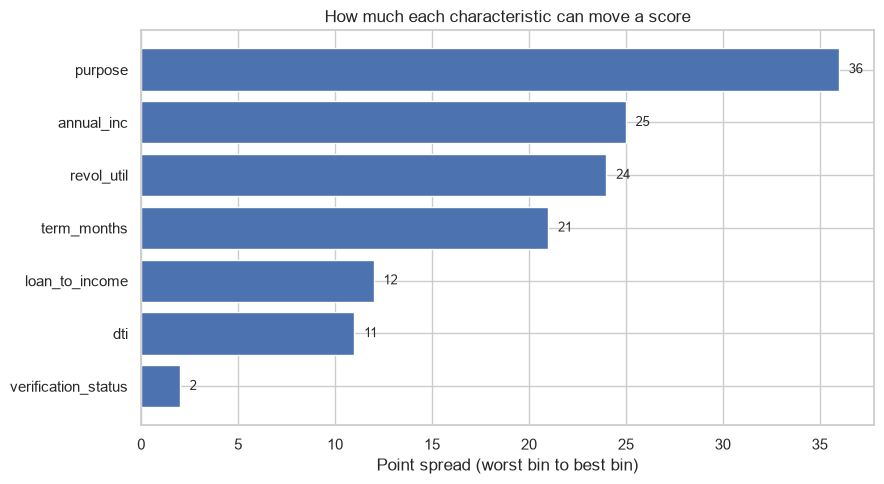

In [10]:
spread = (POINTS.groupby("characteristic").points.agg(["min", "max"])
          .assign(spread=lambda d: d["max"] - d["min"])
          .sort_values("spread", ascending=False))
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(spread.index[::-1], spread.spread[::-1], color="#4C72B0")
ax.set_xlabel("Point spread (worst bin to best bin)")
ax.set_title("How much each characteristic can move a score")
for i, v in enumerate(spread.spread[::-1]):
    ax.text(v + 0.5, i, str(int(v)), va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / "05_point_spread.png", dpi=140)
plt.show()

## 9.7 Scoring by hand

The test that the artefact is real: score one applicant by looking values up
in the table and adding the points, then check it matches the model.

In [11]:
def score_by_lookup(row, verbose=True):
    total, lines = 0, []
    for col in KEEP:
        b = bin_series(pd.Series([row[col]], index=[0]), col).iloc[0]
        match = POINTS[(POINTS.characteristic == col) & (POINTS.bin == str(b))]
        pts = int(match.points.iloc[0]) if len(match) else 0
        total += pts
        lines.append(f"  {col:<24}{str(b):<22}{pts:>6}")
    if verbose:
        print("\n".join(lines))
        print(f"  {'':<24}{'TOTAL':<22}{total:>6}")
    return total


applicant = test.iloc[0]
print("Scoring one applicant from the test set by table lookup:\n")
hand = score_by_lookup(applicant)

# Cross-check against the fitted model
p_model = scorecard_model.predict_proba(Xte_woe.iloc[[0]])[0, 1]
model_score = OFFSET + FACTOR * np.log((1 - p_model) / p_model)
print(f"\nModel score for the same applicant: {model_score:.1f}")
print(f"Hand-added points                 : {hand}")
print(f"Difference                        : {abs(model_score - hand):.2f} (integer rounding)")
assert abs(model_score - hand) < 2, "points table does not reconstruct the model score"
print("\nThe table reproduces the model. It can be used on its own.")

Scoring one applicant from the test set by table lookup:



  loan_to_income          (0.346, inf]              69
  revol_util              (84.7, inf]               66
  dti                     (24.89, inf]              70
  annual_inc              (35000.0, 45000.0]        68
  term_months             36                        81
  purpose                 DEBT_CONSOLIDATION        75
  verification_status     VERIFIED                  75
                          TOTAL                    504

Model score for the same applicant: 502.7
Hand-added points                 : 504
Difference                        : 1.35 (integer rounding)

The table reproduces the model. It can be used on its own.


## 9.8 What the interpretability costs

The comparison that matters. LightGBM from notebook 04 against this scorecard,
on the same held-out test set.

In [12]:
def ks_stat(y_true, p):
    fpr, tpr, _ = roc_curve(y_true, p)
    return float(np.max(tpr - fpr))


p_card = scorecard_model.predict_proba(Xte_woe)[:, 1]
auc_card = roc_auc_score(y_test, p_card)

import joblib
lgbm = joblib.load(ROOT / "outputs" / "models" / "lightgbm.joblib")
cfg = joblib.load(ROOT / "outputs" / "models" / "scorecard_config.joblib")
Xte_tree = test[cfg["TREE_NUM"] + cfg["TREE_CAT"]].copy()
for c in cfg["TREE_CAT"]:
    Xte_tree[c] = pd.Categorical(Xte_tree[c], categories=cfg["tree_categories"][c])
p_lgb = lgbm.predict_proba(Xte_tree)[:, 1]

cmp = pd.DataFrame([
    {"model": "WoE points scorecard", "AUC": round(auc_card, 4),
     "Gini": round(2 * auc_card - 1, 4), "KS": round(ks_stat(y_test, p_card), 4),
     "characteristics": n_chars, "deployable as": "a table"},
    {"model": "LightGBM (notebook 04)", "AUC": round(roc_auc_score(y_test, p_lgb), 4),
     "Gini": round(2 * roc_auc_score(y_test, p_lgb) - 1, 4),
     "KS": round(ks_stat(y_test, p_lgb), 4),
     "characteristics": len(cfg["TREE_NUM"]) + len(cfg["TREE_CAT"]),
     "deployable as": "a serialised model"},
])
cmp

,model,AUC,Gini,KS,characteristics,deployable as
0,WoE points scorecard,0.6740,0.3481,0.2573,7,a table
1,LightGBM (notebook 04),0.6903,0.3805,0.2833,20,a serialised model


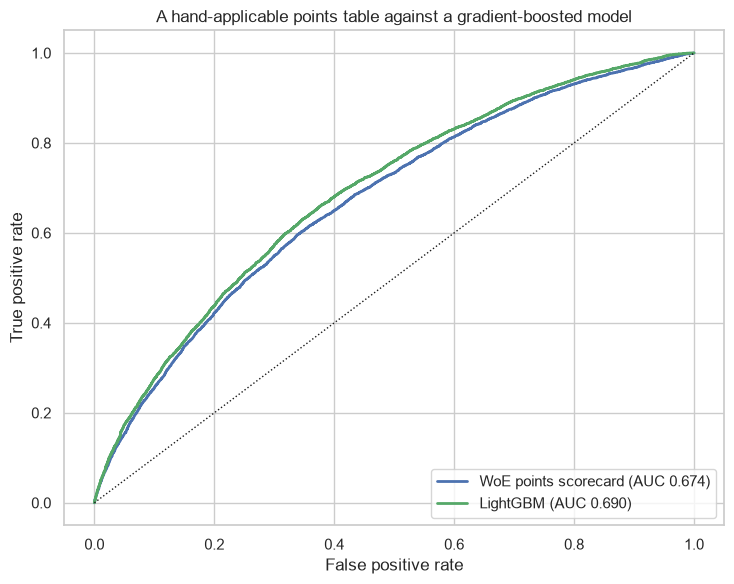

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for name, p, color in [("WoE points scorecard", p_card, "#4C72B0"),
                       ("LightGBM", p_lgb, "#55A868")]:
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_test, p):.3f})", color=color, lw=2)
ax.plot([0, 1], [0, 1], "k:", lw=1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("A hand-applicable points table against a gradient-boosted model")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGS / "05_scorecard_vs_lgbm.png", dpi=140)
plt.show()

## 9.9 Score distribution and monotonicity

The same validation Phase 8 applied, now on the points scorecard.

In [14]:
scores_card = np.clip(OFFSET + FACTOR * np.log((1 - np.clip(p_card, 1e-6, 1 - 1e-6))
                                               / np.clip(p_card, 1e-6, 1 - 1e-6)), 300, 850)
band = pd.qcut(scores_card, 10, duplicates="drop")
by_band = pd.DataFrame({"y": y_test.values, "b": band}).groupby("b", observed=True).y.agg(
    ["size", "mean"])
by_band.columns = ["n", "bad_rate"]
by_band["bad_rate_%"] = (by_band.bad_rate * 100).round(2)
print(by_band[["n", "bad_rate_%"]].to_string())

mono = bool(np.all(np.diff(by_band.bad_rate.values) <= 0))
print(f"\nMonotonic across all ten population deciles: {mono}")
print(f"Risk gradient: {by_band.bad_rate.iloc[0]:.1%} -> {by_band.bad_rate.iloc[-1]:.1%}")
assert mono, "scorecard is not monotonic"

                                 n  bad_rate_%
b                                             
(465.43600000000004, 509.66]  3280       38.54
(509.66, 518.395]             3282       28.21
(518.395, 524.328]            3279       24.40
(524.328, 529.518]            3278       20.38
(529.518, 534.178]            3280       16.49
(534.178, 538.887]            3281       14.96
(538.887, 543.83]             3278       13.76
(543.83, 549.198]             3280       11.37
(549.198, 556.679]            3281        8.14
(556.679, 587.436]            3279        6.77

Monotonic across all ten population deciles: True
Risk gradient: 38.5% -> 6.8%


In [15]:
POINTS.to_csv(ROOT / "outputs" / "scorecard_points.csv", index=False)
joblib.dump({"BIN_EDGES": BIN_EDGES, "WOE_MAPS": WOE_MAPS, "KEEP": KEEP,
             "coefs": coefs.to_dict(), "intercept": intercept,
             "FACTOR": FACTOR, "OFFSET": OFFSET},
            ROOT / "outputs" / "models" / "points_scorecard.joblib")
print("Saved outputs/scorecard_points.csv and outputs/models/points_scorecard.joblib")

Saved outputs/scorecard_points.csv and outputs/models/points_scorecard.joblib


## Phase 9 summary

**The deliverable is `outputs/scorecard_points.csv`** — a points table that
can be applied by hand, audited row by row, and deployed without running a
model at all.

**What it cost.** The comparison in §9.8 is the honest answer to "why not just
use the gradient-boosted model?" The gap is small, and in exchange the
scorecard is a document rather than a binary artefact: every number in it has
a visible derivation, and a declined applicant can be shown the exact rows
that cost them points.

**Monotonicity is enforced twice** — once in the coarse classing, so no
characteristic prices a non-monotonic story, and once on the final score
distribution.

**The hand-scoring check in §9.7 is the proof the artefact is real.** Adding
up the table by lookup reproduces the fitted model's score to within integer
rounding. If that assertion ever fails, the table and the model have drifted
apart and the table is the one people would be using.